In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from helpers import *
from missing_features_helper import DropHighMissingFeatures
import math

In [2]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RepeatedStratifiedKFold
from sklearn.preprocessing import PowerTransformer #  Example: PowerTransformer(method='box-cox', standardize=False)
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer, KNNImputer
# explicitly require this experimental feature
from sklearn.experimental import enable_iterative_imputer  # noqa
# now you can import normally from sklearn.impute
from sklearn.impute import IterativeImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel, RFE
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [3]:
pd.set_option('display.max_columns', None)   
pd.set_option('display.max_rows', None)   

## Importing the data and merging it

In [4]:
data = pd.read_csv('../raw_data/secom.data', header=None, delimiter=" ")
labels = pd.read_csv('../raw_data/secom_labels.data', header=None, delimiter=" ")

In [5]:
data.shape

(1567, 590)

In [6]:
data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511,512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,-0.0034,0.9455,202.4396,0.0,7.9558,414.8710,10.0433,0.9680,192.3963,12.5190,1.4026,-5419.00,2916.50,-4043.75,751.00,0.8955,1.7730,3.0490,64.2333,2.0222,0.1632,3.5191,83.3971,9.5126,50.6170,64.2588,49.3830,66.3141,86.9555,117.5132,61.29,4.515,70.0,352.7173,10.1841,130.3691,723.3092,1.3072,141.2282,1.0,624.3145,218.3174,0.0,4.592,4.841,2834.0,0.9317,0.9484,4.7057,-1.7264,350.9264,10.6231,108.6427,16.1445,21.7264,29.5367,693.7724,0.9226,148.6009,1.0,608.1700,84.0793,NaN,NaN,0.0,0.0126,-0.0206,0.0141,-0.0307,-0.0083,-0.0026,-0.0567,-0.0044,7.2163,0.1320,NaN,2.3895,0.9690,1747.6049,0.1841,8671.9301,-0.3274,-0.0055,-0.0001,0.0001,0.0003,-0.2786,0.0,0.3974,-0.0251,0.0002,0.0002,0.1350,-0.0042,0.0003,0.0056,0.0000,-0.2468,0.3196,NaN,NaN,NaN,NaN,0.9460,0.0,748.6115,0.9908,58.4306,0.6002,0.9804,6.3788,15.88,2.639,15.94,15.93,0.8656,3.353,0.4098,3.188,-0.0473,0.7243,0.9960,2.2967,1000.7263,39.2373,123.0,111.3,75.2,46.2000,350.6710,0.3948,0.0,6.78,0.0034,0.0898,0.0850,0.0358,0.0328,12.2566,0.0,4.271,10.284,0.4734,0.0167,11.8901,0.41,0.0506,NaN,NaN,1017.0,967.0,1066.0,368.0,0.090,0.048,0.095,2.0,0.9,0.069,0.046,0.7250,0.1139,0.3183,0.5888,0.3184,0.9499,0.3979,0.160,0.0,0.0,20.95,0.333,12.49,16.713,0.0803,5.72,0.0,11.19,65.363,0.0,0.0,0.0,0.0,0.0,0.0,0.292,5.38,20.10,0.296,10.62,10.30,5.38,4.040,16.230,0.2951,8.64,0.0,10.30,97.314,0.0,0.0772,0.0599,0.0700,0.0547,0.0704,0.0520,0.0301,0.1135,3.4789,0.0010,NaN,0.0707,0.0211,175.2173,0.0315,1940.3994,0.0,0.0744,0.0546,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0027,0.0040,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0188,0.0,219.9453,0.0011,2.8374,0.0189,0.0050,0.4269,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0472,40.855

In [7]:
labels.head()

,0,1
0,-1,19/07/2008 11:55:00
1,-1,19/07/2008 12:32:00
2,1,19/07/2008 13:17:00
3,-1,19/07/2008 14:43:00
4,-1,19/07/2008 15:22:00


In [8]:
labels.shape

(1567, 2)

### Rename label columns 

In [9]:
labels = labels.rename({0: "Label", 1: "timestamp"}, axis='columns')

In [10]:
df = data.merge(labels, left_index=True, right_index=True)

In [11]:
df.shape

(1567, 592)

In [12]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511,512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,Label,timestamp
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,-0.0034,0.9455,202.4396,0.0,7.9558,414.8710,10.0433,0.9680,192.3963,12.5190,1.4026,-5419.00,2916.50,-4043.75,751.00,0.8955,1.7730,3.0490,64.2333,2.0222,0.1632,3.5191,83.3971,9.5126,50.6170,64.2588,49.3830,66.3141,86.9555,117.5132,61.29,4.515,70.0,352.7173,10.1841,130.3691,723.3092,1.3072,141.2282,1.0,624.3145,218.3174,0.0,4.592,4.841,2834.0,0.9317,0.9484,4.7057,-1.7264,350.9264,10.6231,108.6427,16.1445,21.7264,29.5367,693.7724,0.9226,148.6009,1.0,608.1700,84.0793,NaN,NaN,0.0,0.0126,-0.0206,0.0141,-0.0307,-0.0083,-0.0026,-0.0567,-0.0044,7.2163,0.1320,NaN,2.3895,0.9690,1747.6049,0.1841,8671.9301,-0.3274,-0.0055,-0.0001,0.0001,0.0003,-0.2786,0.0,0.3974,-0.0251,0.0002,0.0002,0.1350,-0.0042,0.0003,0.0056,0.0000,-0.2468,0.3196,NaN,NaN,NaN,NaN,0.9460,0.0,748.6115,0.9908,58.4306,0.6002,0.9804,6.3788,15.88,2.639,15.94,15.93,0.8656,3.353,0.4098,3.188,-0.0473,0.7243,0.9960,2.2967,1000.7263,39.2373,123.0,111.3,75.2,46.2000,350.6710,0.3948,0.0,6.78,0.0034,0.0898,0.0850,0.0358,0.0328,12.2566,0.0,4.271,10.284,0.4734,0.0167,11.8901,0.41,0.0506,NaN,NaN,1017.0,967.0,1066.0,368.0,0.090,0.048,0.095,2.0,0.9,0.069,0.046,0.7250,0.1139,0.3183,0.5888,0.3184,0.9499,0.3979,0.160,0.0,0.0,20.95,0.333,12.49,16.713,0.0803,5.72,0.0,11.19,65.363,0.0,0.0,0.0,0.0,0.0,0.0,0.292,5.38,20.10,0.296,10.62,10.30,5.38,4.040,16.230,0.2951,8.64,0.0,10.30,97.314,0.0,0.0772,0.0599,0.0700,0.0547,0.0704,0.0520,0.0301,0.1135,3.4789,0.0010,NaN,0.0707,0.0211,175.2173,0.0315,1940.3994,0.0,0.0744,0.0546,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0027,0.0040,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0188,0.0,219.9453,0.0011,2.8374,0.0189,0.0050,0.4269,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

## Phase 2: Initial Data Inspection

#### Count rows, columns, pass examples, fail examples, and failure percentage.

In [13]:
# Rows and Columns count
print(f'Amount of rows {df.shape[0]}')
print(f'Amount of columns {df.shape[1]}')

Amount of rows 1567
Amount of columns 592


In [14]:
pass_fail = df.Label.value_counts()

In [15]:
df.Label.value_counts(normalize=True)

Label
-1    0.933631
 1    0.066369
Name: proportion, dtype: float64

In [16]:
print(f'Pass example count {pass_fail[-1]} that is 93.3631% of the total')
print(f'Fail example count {pass_fail[1]} that is the 6.6369% of the total')

Pass example count 1463 that is 93.3631% of the total
Fail example count 104 that is the 6.6369% of the total


### Checking for null values

In [17]:
df.isnull().sum()

0               6
1               7
2              14
3              14
4              14
5              14
6              14
7               9
8               2
9               2
10              2
11              2
12              2
13              3
14              3
15              3
16              3
17              3
18              3
19             10
20              0
21              2
22              2
23              2
24              2
25              2
26              2
27              2
28              2
29              2
30              2
31              2
32              1
33              1
34              1
35              1
36              1
37              1
38              1
39              1
40             24
41             24
42              1
43              1
44              1
45              1
46              1
47              1
48              1
49              1
50              1
51              1
52              1
53              4
54              4
55        

##### Total of null values

In [18]:
df.isnull().sum().sum()

np.int64(41951)

### Identify constant and near-constant features.

>Constant features are identified as columns with one or fewer unique non-missing values. Near-constant features are identified as columns where one observed value accounted for at least 98% of the non-missing observations. These features are reviewed because they provide little variation for distinguishing pass and fail examples.

In [19]:
report = constant_near_constant_report(df.drop(columns=["Label"]), near_constant_threshold=0.98)

In [20]:
report.head()

,feature,n_rows,n_missing,missing_rate,n_unique_non_missing,n_unique_including_missing,most_common_value,most_common_count,dominance_rate_non_missing,dominance_rate_total,is_constant,is_near_constant
5,5,1567,14,0.008934,1,2,100.0,1553,1.0,0.991066,True,False
13,13,1567,3,0.001914,1,2,0.0,1564,1.0,0.998086,True,False
42,42,1567,1,0.000638,1,2,70.0,1566,1.0,0.999362,True,False
49,49,1567,1,0.000638,1,2,1.0,1566,1.0,0.999362,True,False
52,52,1567,1,0.000638,1,2,0.0,1566,1.0,0.999362,True,False


#### Maximum number of null values in the "is_constant" columns

In [21]:
report[report['is_constant'] == True]['n_missing'].max()

np.int64(24)

In [22]:
report[report['is_constant'] == True]['n_unique_including_missing'].max()

np.int64(2)

Only 2 values in the "is_constant" cols. 1 value and the NaN values. Those columns will be removed

#### Columns names when the values are constant 

In [23]:
constant_features = report[report['is_constant'] == True]['feature'].values
constant_features

array([5, 13, 42, 49, 52, 69, 97, 141, 149, 178, 179, 186, 189, 190, 191,
       192, 193, 194, 226, 229, 230, 231, 232, 233, 234, 235, 236, 237,
       240, 241, 242, 243, 256, 257, 258, 259, 260, 261, 262, 263, 264,
       265, 266, 276, 284, 313, 314, 315, 322, 325, 326, 327, 328, 329,
       330, 364, 369, 370, 371, 372, 373, 374, 375, 378, 379, 380, 381,
       394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 414, 422,
       449, 450, 451, 458, 461, 462, 463, 464, 465, 466, 481, 498, 501,
       502, 503, 504, 505, 506, 507, 508, 509, 512, 513, 514, 515, 528,
       529, 530, 531, 532, 533, 534, 535, 536, 537, 538], dtype=object)

#### Near constant features

In [24]:
report[report['is_near_constant'] == True]

,feature,n_rows,n_missing,missing_rate,n_unique_non_missing,n_unique_including_missing,most_common_value,most_common_count,dominance_rate_non_missing,dominance_rate_total,is_constant,is_near_constant
74,74,1567,6,0.003829,2,3,0.0,1560,0.999359,0.995533,False,True
206,206,1567,6,0.003829,2,3,0.0,1560,0.999359,0.995533,False,True
209,209,1567,6,0.003829,2,3,0.0,1560,0.999359,0.995533,False,True
342,342,1567,6,0.003829,2,3,0.0,1560,0.999359,0.995533,False,True
347,347,1567,6,0.003829,2,3,0.0,1560,0.999359,0.995533,False,True
478,478,1567,6,0.003829,2,3,0.0,1560,0.999359,0.995533,False,True
521,521,1567,0,0.000000,9,9,0.0,1546,0.986599,0.986599,False,True
114,114,1567,0,0.000000,20,20,0.0,1545,0.985960,0.985960,False,True
249,249,1567,0,0.000000,23,23,0.0,1545,0.985960,0.985960,False,True
387,387,1567,0,0.000000,22,22,0.0,1545,0.985960,0.985960,False,True


In [25]:
df[13].unique()

array([ 0., nan])

In [26]:
near_constant_features = report.loc[(report["is_near_constant"] == True) & (report["n_unique_including_missing"] < 9), "feature"].tolist()

In [27]:
len(near_constant_features)

6

In [28]:
len(constant_features)

116

In [29]:
for threshold in [0.95, 0.98, 0.99]:
    report = constant_near_constant_report(df.drop(columns=["Label"]), near_constant_threshold=threshold)
    print(
        threshold,
        "constant:",
        report["is_constant"].sum(),
        "near-constant:",
        report["is_near_constant"].sum()
    )

0.95 constant: 116 near-constant: 10
0.98 constant: 116 near-constant: 10
0.99 constant: 116 near-constant: 6


In [30]:
len(list(constant_features) + near_constant_features)

122

In [31]:
df_no_constant_cols = df.drop(columns=list(constant_features) + near_constant_features)

In [32]:
df_no_constant_cols.head()

,0,1,2,3,4,6,7,8,9,10,11,12,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,46,47,48,50,51,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,70,71,72,73,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,142,143,144,145,146,147,148,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,180,181,182,183,184,185,187,188,195,196,197,198,199,200,201,202,203,204,205,207,208,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,227,228,238,239,244,245,246,247,248,249,250,251,252,253,254,255,267,268,269,270,271,272,273,274,275,277,278,279,280,281,282,283,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,316,317,318,319,320,321,323,324,331,332,333,334,335,336,337,338,339,340,341,343,344,345,346,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,365,366,367,368,376,377,382,383,384,385,386,387,388,389,390,391,392,393,405,406,407,408,409,410,411,412,413,415,416,417,418,419,420,421,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,452,453,454,455,456,457,459,460,467,468,469,470,471,472,473,474,475,476,477,479,480,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,499,500,510,511,516,517,518,519,520,521,522,523,524,525,526,527,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,Label,timestamp
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,0.1242,1.5005,0.0162,-0.0034,0.9455,202.4396,7.9558,414.8710,10.0433,0.9680,192.3963,12.5190,1.4026,-5419.00,2916.50,-4043.75,751.00,0.8955,1.7730,3.0490,64.2333,2.0222,0.1632,3.5191,83.3971,9.5126,50.6170,64.2588,49.3830,66.3141,86.9555,117.5132,61.29,4.515,352.7173,10.1841,130.3691,723.3092,1.3072,141.2282,624.3145,218.3174,4.592,4.841,2834.0,0.9317,0.9484,4.7057,-1.7264,350.9264,10.6231,108.6427,16.1445,21.7264,29.5367,693.7724,0.9226,148.6009,608.1700,84.0793,NaN,NaN,0.0126,-0.0206,0.0141,-0.0307,-0.0083,-0.0026,-0.0567,-0.0044,7.2163,0.1320,NaN,2.3895,0.9690,1747.6049,0.1841,8671.9301,-0.3274,-0.0055,-0.0001,0.0001,0.0003,-0.2786,0.3974,-0.0251,0.0002,0.0002,0.1350,-0.0042,0.0003,0.0056,0.0000,-0.2468,0.3196,NaN,NaN,NaN,NaN,0.9460,0.0,748.6115,0.9908,58.4306,0.6002,0.9804,6.3788,15.88,2.639,15.94,15.93,0.8656,3.353,0.4098,3.188,-0.0473,0.7243,0.9960,2.2967,1000.7263,39.2373,123.0,111.3,75.2,46.2000,350.6710,0.3948,6.78,0.0034,0.0898,0.0850,0.0358,0.0328,12.2566,4.271,10.284,0.4734,0.0167,11.8901,0.41,0.0506,NaN,NaN,1017.0,967.0,1066.0,368.0,0.090,0.048,0.095,2.0,0.9,0.069,0.046,0.7250,0.1139,0.3183,0.5888,0.3184,0.9499,0.3979,0.160,20.95,0.333,12.49,16.713,0.0803,5.72,11.19,65.363,0.292,5.38,20.10,0.296,10.62,10.30,5.38,4.040,16.230,0.2951,8.64,10.30,97.314,0.0772,0.0599,0.0700,0.0547,0.0704,0.0520,0.0301,0.1135,3.4789,0.0010,NaN,0.0707,0.0211,175.2173,0.0315,1940.3994,0.0744,0.0546,0.0027,0.0040,NaN,NaN,NaN,NaN,0.0188,0.0,219.9453,0.0011,2.8374,0.0189,0.0050,0.4269,0.0472,40.855,4.5152,30.9815,33.9606,22.9057,15.9525,110.2144,0.1310,2.5883,0.0010,0.0319,0.0197,0.0120,0.0109,3.9321,1.5123,3.5811,0.1337,0.0055,3.8447,0.1077,0.0167,NaN,NaN,418.1363,398.3185,496.1582,158.3330,0.0373,0.0202,0.0462,0.6083,0.3032,0.0200,0.0174,0.2827,0.0434,0.1342,0.2419,0.1343,0.3670,0.1431,0.0610,6.2698,0.1181,3.8208,5.3737,0.0254,1.6252,3.2461,18.0118,0.0752,1.5989,6.5893,0.0913,3.0911,8.4654,1.5989,1.2293,5.3406,0.0867,2.8551,2.9971,31.8843,NaN,NaN,0.0215,0.0274,0.0315,0.0238,0.0206,0.0238,0.0144,0.0491,1.2708,0.0004,NaN,0.0229,0.0065,55.2039,0.0105,560.2658,0.0170,0.0148,0.0124,0.0114,0.0010,0.0013,NaN,NaN,NaN,NaN,0.0055,0.0,61.5932,0

## Phase 3: Missingness as Process Information

### Check duplicate rows and feature types

In [33]:
data.duplicated().sum()

np.int64(0)

No duplicate rows in the dataset

In [34]:
df_no_constant_cols.dtypes.value_counts()

float64    468
int64        1
str          1
Name: count, dtype: int64

In [35]:
print(f'Label column is integer (-1, 1) \nTimestamp column string (needs to be converted to datetime)\nThe rest of the columns are float data type')

Label column is integer (-1, 1) 
Timestamp column string (needs to be converted to datetime)
The rest of the columns are float data type


##### Convert datetime column fron string to datetime

In [36]:
df_no_constant_cols.timestamp = pd.to_datetime(df_no_constant_cols.timestamp, format="%d/%m/%Y %H:%M:%S")

In [37]:
df_no_constant_cols.head()

,0,1,2,3,4,6,7,8,9,10,11,12,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,46,47,48,50,51,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,70,71,72,73,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,142,143,144,145,146,147,148,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,180,181,182,183,184,185,187,188,195,196,197,198,199,200,201,202,203,204,205,207,208,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,227,228,238,239,244,245,246,247,248,249,250,251,252,253,254,255,267,268,269,270,271,272,273,274,275,277,278,279,280,281,282,283,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,316,317,318,319,320,321,323,324,331,332,333,334,335,336,337,338,339,340,341,343,344,345,346,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,365,366,367,368,376,377,382,383,384,385,386,387,388,389,390,391,392,393,405,406,407,408,409,410,411,412,413,415,416,417,418,419,420,421,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,452,453,454,455,456,457,459,460,467,468,469,470,471,472,473,474,475,476,477,479,480,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,499,500,510,511,516,517,518,519,520,521,522,523,524,525,526,527,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,Label,timestamp
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,0.1242,1.5005,0.0162,-0.0034,0.9455,202.4396,7.9558,414.8710,10.0433,0.9680,192.3963,12.5190,1.4026,-5419.00,2916.50,-4043.75,751.00,0.8955,1.7730,3.0490,64.2333,2.0222,0.1632,3.5191,83.3971,9.5126,50.6170,64.2588,49.3830,66.3141,86.9555,117.5132,61.29,4.515,352.7173,10.1841,130.3691,723.3092,1.3072,141.2282,624.3145,218.3174,4.592,4.841,2834.0,0.9317,0.9484,4.7057,-1.7264,350.9264,10.6231,108.6427,16.1445,21.7264,29.5367,693.7724,0.9226,148.6009,608.1700,84.0793,NaN,NaN,0.0126,-0.0206,0.0141,-0.0307,-0.0083,-0.0026,-0.0567,-0.0044,7.2163,0.1320,NaN,2.3895,0.9690,1747.6049,0.1841,8671.9301,-0.3274,-0.0055,-0.0001,0.0001,0.0003,-0.2786,0.3974,-0.0251,0.0002,0.0002,0.1350,-0.0042,0.0003,0.0056,0.0000,-0.2468,0.3196,NaN,NaN,NaN,NaN,0.9460,0.0,748.6115,0.9908,58.4306,0.6002,0.9804,6.3788,15.88,2.639,15.94,15.93,0.8656,3.353,0.4098,3.188,-0.0473,0.7243,0.9960,2.2967,1000.7263,39.2373,123.0,111.3,75.2,46.2000,350.6710,0.3948,6.78,0.0034,0.0898,0.0850,0.0358,0.0328,12.2566,4.271,10.284,0.4734,0.0167,11.8901,0.41,0.0506,NaN,NaN,1017.0,967.0,1066.0,368.0,0.090,0.048,0.095,2.0,0.9,0.069,0.046,0.7250,0.1139,0.3183,0.5888,0.3184,0.9499,0.3979,0.160,20.95,0.333,12.49,16.713,0.0803,5.72,11.19,65.363,0.292,5.38,20.10,0.296,10.62,10.30,5.38,4.040,16.230,0.2951,8.64,10.30,97.314,0.0772,0.0599,0.0700,0.0547,0.0704,0.0520,0.0301,0.1135,3.4789,0.0010,NaN,0.0707,0.0211,175.2173,0.0315,1940.3994,0.0744,0.0546,0.0027,0.0040,NaN,NaN,NaN,NaN,0.0188,0.0,219.9453,0.0011,2.8374,0.0189,0.0050,0.4269,0.0472,40.855,4.5152,30.9815,33.9606,22.9057,15.9525,110.2144,0.1310,2.5883,0.0010,0.0319,0.0197,0.0120,0.0109,3.9321,1.5123,3.5811,0.1337,0.0055,3.8447,0.1077,0.0167,NaN,NaN,418.1363,398.3185,496.1582,158.3330,0.0373,0.0202,0.0462,0.6083,0.3032,0.0200,0.0174,0.2827,0.0434,0.1342,0.2419,0.1343,0.3670,0.1431,0.0610,6.2698,0.1181,3.8208,5.3737,0.0254,1.6252,3.2461,18.0118,0.0752,1.5989,6.5893,0.0913,3.0911,8.4654,1.5989,1.2293,5.3406,0.0867,2.8551,2.9971,31.8843,NaN,NaN,0.0215,0.0274,0.0315,0.0238,0.0206,0.0238,0.0144,0.0491,1.2708,0.0004,NaN,0.0229,0.0065,55.2039,0.0105,560.2658,0.0170,0.0148,0.0124,0.0114,0.0010,0.0013,NaN,NaN,NaN,NaN,0.0055,0.0,61.5932,0

#### Calculate missing percentage per feature.

In [38]:
col_50_pre_null_val = df_no_constant_cols.columns[df_no_constant_cols.isnull().mean() > 0.5]

In [39]:
len(col_50_pre_null_val)

28

There are 28 columns where missing percentage is greater than 50%

#### Compare missingness rates between pass and fail groups.

In [40]:
missingness_target_report = missingness_by_target_report(df_no_constant_cols.drop(columns='Label'), df_no_constant_cols.Label)

In [41]:
missingness_target_report['feature'].nunique()

469

In [42]:
(missingness_target_report.pass_missing_rate > 0.65).sum()

np.int64(8)

8 features with pass missing rate greater that 0.65 (almost the whole dataset)

In [43]:
missingness_target_report[(missingness_target_report.pass_missing_rate > 0.65)]

,feature,n_pass,n_fail,pass_missing_count,fail_missing_count,total_missing_count,pass_missing_rate,fail_missing_rate,missing_rate_diff_fail_minus_pass,fail_share_among_missing,all_fails_missing,missing_only_when_fail,perfect_failure_missing_signal,exact_match_fail_flag
78,85,1463,104,1248,93,1341,0.853042,0.894231,0.041189,0.069351,False,False,False,False
199,220,1463,104,1248,93,1341,0.853042,0.894231,0.041189,0.069351,False,False,False,False
298,358,1463,104,1248,93,1341,0.853042,0.894231,0.041189,0.069351,False,False,False,False
395,492,1463,104,1248,93,1341,0.853042,0.894231,0.041189,0.069351,False,False,False,False
147,157,1463,104,1333,96,1429,0.911141,0.923077,0.011935,0.067180,False,False,False,False
148,158,1463,104,1333,96,1429,0.911141,0.923077,0.011935,0.067180,False,False,False,False
244,292,1463,104,1333,96,1429,0.911141,0.923077,0.011935,0.067180,False,False,False,False
245,293,1463,104,1333,96,1429,0.911141,0.923077,0.011935,0.067180,False,False,False,False


In [44]:
print(f'Amount of features with all failures missing: {len(missingness_target_report[missingness_target_report["all_fails_missing"] == True])}')
print(f'Amount of features with missing values only when failure occurs: {len(missingness_target_report[missingness_target_report["missing_only_when_fail"] == True])}')

print(f'Amount of features with perfect failure missing signal: {len(missingness_target_report[missingness_target_report["perfect_failure_missing_signal"] == True])}')
print(f'Amount of features with exact match failure flag: {len(missingness_target_report[missingness_target_report["exact_match_fail_flag"] == True])}')

Amount of features with all failures missing: 0
Amount of features with missing values only when failure occurs: 0
Amount of features with perfect failure missing signal: 0
Amount of features with exact match failure flag: 0


In [45]:
print(f'Amount of features with exact match fail flag: {len(missingness_target_report[missingness_target_report["exact_match_fail_flag"] == True])}')

Amount of features with exact match fail flag: 0


In [46]:
print(f'Amount of features with missing rate difference between failure and pass: {len(missingness_target_report[missingness_target_report["missing_rate_diff_fail_minus_pass"] == True])}')

Amount of features with missing rate difference between failure and pass: 0


## What this table means

Each feature is evaluated on:
- `pass_missing_rate`: fraction of pass rows where the feature is missing
- `fail_missing_rate`: fraction of fail rows where the feature is missing
- `missing_rate_diff_fail_minus_pass`: how much more often the feature is missing in fails vs passes
- `fail_share_among_missing`: among rows where the feature is missing, what share are failures

It also flags suspicious patterns:
- `all_fails_missing`: every failing row has this feature missing
- `missing_only_when_fail`: only failing rows have missing values for this feature
- `perfect_failure_missing_signal`: missingness perfectly separates fail vs pass
- `exact_match_fail_flag`: missing pattern exactly matches the failure label

---

## What the sample output shows

From the rows shown:
- Features like `109, 110, 111, 244, 245, 246, 382, 383, 384, 516, 517, 518`
  - have very high missingness overall
  - are missing slightly more often in fails than passes
  - but do not trigger any extreme leakage flags
- Features `562`–`569` show a similar pattern at lower overall missingness
- Feature `85` is missing in most rows and also has only a small fail/pass difference

So these are likely “features with a missingness signal,” not “features that perfectly leak the label.”

---

## Key interpretation

- A feature with `fail_missing_rate > pass_missing_rate` may be informative, but it is not necessarily a safe predictive feature.
- The most suspicious cases are when:
  - `perfect_failure_missing_signal == True`, or
  - `exact_match_fail_flag == True`, or
  - `missing_only_when_fail == True`
- The shown rows do not appear to be the extreme leakage cases.

---

## Recommendation

For a stronger conclusion:
1. check whether any rows in `missingness_target_report` have `perfect_failure_missing_signal == True`
2. check whether any rows have `exact_match_fail_flag == True`
3. review features with the highest `missing_rate_diff_fail_minus_pass`

> No desicion about the missigness will be made at this time

In [47]:
(df_no_constant_cols.isnull().sum()).sort_values(ascending=False).head(10)

292    1429
158    1429
157    1429
293    1429
85     1341
358    1341
220    1341
492    1341
516    1018
109    1018
dtype: int64

In [48]:
len(df_no_constant_cols.columns)

470

In [49]:
1429 /  df_no_constant_cols.shape[0]

0.9119336311423102

There are several columns that have more than 90% of missing values.

In [50]:
feature_to_drop_due_to_missignes = list(missingness_target_report[(missingness_target_report.pass_missing_rate > 0.65)]['feature'])

### Dropping features with more that 80% of issing values (that happend to be greater that 65%)

In [51]:
df_no_constant_cols = df_no_constant_cols.drop(columns=feature_to_drop_due_to_missignes)

## Phase 4: Target Imbalance and Manufacturing Risk

In [52]:
df_no_constant_cols.Label.value_counts()

Label
-1    1463
 1     104
Name: count, dtype: int64

> Pass example count 1463 that is 93.36% of the total <br>
> Fail example count 104 that is the 6.64% of the total

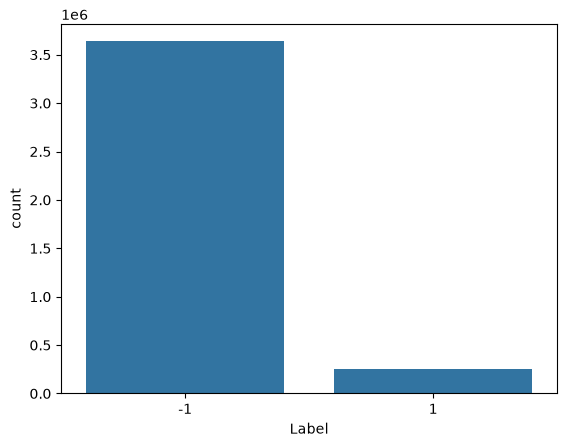

In [53]:
sns.countplot(df_no_constant_cols, x='Label');

| Class | Label | Count | Percentage |
| ----- | ----: | ----: | ---------: |
| Pass  |    -1 | 1,463 |     93.36% |
| Fail  |     1 |   104 |      6.64% |

### Phase 5

In [54]:
df_no_constant_cols.describe().T

,count,mean,min,25%,50%,75%,max,std
0,1561.0,3014.452896,2743.24,2966.26,3011.49,3056.65,3356.35,73.621787
1,1560.0,2495.850231,2158.75,2452.2475,2499.405,2538.8225,2846.44,80.407705
2,1553.0,2200.547318,2060.66,2181.0444,2201.0667,2218.0555,2315.2667,29.513152
3,1553.0,1396.376627,0.0,1081.8758,1285.2144,1591.2235,3715.0417,441.69164
4,1553.0,4.197013,0.6815,1.0177,1.3168,1.5257,1114.5366,56.35554
6,1553.0,101.112908,82.1311,97.92,101.5122,104.5867,129.2522,6.237214
7,1558.0,0.121822,0.0,0.1211,0.1224,0.1238,0.1286,0.008961
8,1565.0,1.462862,1.191,1.4112,1.4616,1.5169,1.6564,0.073897
9,1565.0,-0.000841,-0.0534,-0.0108,-0.0013,0.0084,0.0749,0.015116
10,1565.0,0.000146,-0.0349,-0.0056,0.0004,0.0059,0.053,0.009302


In [55]:
eda_report = build_feature_eda_report(
    X=df_no_constant_cols.drop(columns=["Label", "timestamp"]),
    y=df_no_constant_cols.Label
)

In [56]:
eda_report.shape

(460, 35)

In [57]:
eda_report.outlier_count.median()

np.float64(39.5)

### Which features differ most between pass and fail?

In [58]:
pass_fail_candidates = (
    eda_report
    .sort_values(
        "abs_standardized_mean_difference",
        ascending=False
    )
    .head(30)
)

pass_fail_candidates[
    [
        "feature",
        "pass_mean",
        "fail_mean",
        "standardized_mean_difference",
    ]
]

,feature,pass_mean,fail_mean,standardized_mean_difference
54,59,2.563464,8.515123,0.631888
94,103,-0.009913,-0.008053,0.613731
395,510,54.440591,74.347949,0.532625
282,348,0.024291,0.030448,0.523349
102,111,231.876523,230.821983,-0.503717
339,431,21.191221,38.924103,0.490669
342,434,13.719237,29.136890,0.454736
338,430,17.368450,33.370198,0.446322
343,435,8.376004,23.489069,0.442217
19,21,-5636.437585,-5362.274272,0.439842


In [59]:
features_differ_most_between_pass_and_fail = pass_fail_candidates.feature

In [60]:
len(features_differ_most_between_pass_and_fail)

30

### Which features have failures in extreme ranges?

In [61]:
failure_extreme_candidates = (
    eda_report
    .sort_values(
        "fail_extreme_rate",
        ascending=False
    )
    .head(30)
)

failure_extreme_candidates[
    [
        "feature",
        "pass_lower_5pct",
        "pass_upper_95pct",
        "fail_extreme_rate",
        "fail_low_extreme_rate",
        "fail_high_extreme_rate",
    ]
].sort_values("fail_extreme_rate", ascending=False)

,feature,pass_lower_5pct,pass_upper_95pct,fail_extreme_rate,fail_low_extreme_rate,fail_high_extreme_rate
59,64,13.824100,29.101125,0.288462,0.105769,0.182692
60,65,18.625950,37.523975,0.288462,0.105769,0.182692
23,25,0.968800,1.331000,0.242718,0.135922,0.106796
282,348,0.013680,0.042600,0.230769,0.076923,0.153846
277,341,1.304380,4.143460,0.221154,0.038462,0.182692
57,62,106.357100,127.776880,0.221154,0.125000,0.096154
62,67,0.813780,1.351980,0.211538,0.096154,0.115385
36,38,86.273200,87.489000,0.211538,0.067308,0.144231
375,477,2.811420,9.816120,0.201923,0.038462,0.163462
0,0,2907.030000,3127.278000,0.201923,0.096154,0.105769


In [62]:
features_have_failures_in_extreme_ranges = failure_extreme_candidates.feature

### Which features are strongly skewed?

In [63]:
skewed_features = (
    eda_report
    .assign(abs_skew=lambda d: d["skew"].abs())
    .sort_values(
        "abs_skew",
        ascending=False
    )
    .head(30)
)

In [64]:
features_are_strongly_skewed = skewed_features.feature

In [65]:
outlier_candidates = (
    eda_report
    .sort_values(
        "outlier_rate",
        ascending=False
    )
    .head(30)
)

outlier_candidates[
    [
        "feature",
        "outlier_count",
        "outlier_rate",
        "skew",
    ]
]

,feature,outlier_count,outlier_rate,skew
29,31,354,0.226198,1.157933
38,40,330,0.213869,-1.868022
432,562,215,0.166151,0.105871
120,129,238,0.152760,-0.976433
414,544,239,0.152716,0.117641
258,312,234,0.149425,1.879530
173,195,233,0.149072,10.416949
164,177,230,0.146871,1.834397
356,448,230,0.146871,1.767543
365,467,218,0.139475,10.441276


In [66]:
features_with_higher_outliers_rate = outlier_candidates.feature

In [67]:
eda_report = add_behavior_flags(
    eda_report
)

In [68]:
eda_report[
    "candidate_process_signal"
].value_counts()

candidate_process_signal
False    422
True      38
Name: count, dtype: int64

In [69]:
candidate_features = eda_report[
    eda_report["candidate_process_signal"]
].copy()

candidate_features.shape

(38, 41)

In [70]:
eda_report["eda_priority_score"] = (
    eda_report[
        "abs_standardized_mean_difference"
    ].fillna(0)
    +
    eda_report[
        "fail_extreme_rate"
    ].fillna(0)
    +
    eda_report[
        "outlier_rate"
    ].fillna(0)
)

In [71]:
eda_shortlist = (
    eda_report
    .sort_values(
        "eda_priority_score",
        ascending=False
    )
    .head(30)
)

eda_shortlist[
    [
        "feature",
        "missing_rate",
        "abs_standardized_mean_difference",
        "fail_extreme_rate",
        "outlier_rate",
        "skew",
        "eda_priority_score",
    ]
]

,feature,missing_rate,abs_standardized_mean_difference,fail_extreme_rate,outlier_rate,skew,eda_priority_score
54,59,0.004467,0.631888,0.173077,0.125641,4.719467,0.930606
282,348,0.015316,0.523349,0.230769,0.064809,5.286112,0.818927
94,103,0.001276,0.613731,0.163462,0.017891,0.831421,0.795084
395,510,0.001276,0.532625,0.163462,0.058147,4.106694,0.754234
339,431,0.001276,0.490669,0.135922,0.052396,7.098779,0.678988
338,430,0.001276,0.446322,0.145631,0.074760,7.389605,0.666714
186,210,0.015316,0.410911,0.182692,0.064161,3.852972,0.657764
343,435,0.001276,0.442217,0.165049,0.040895,8.660243,0.648160
120,129,0.005743,0.416129,0.076923,0.152760,-0.976433,0.645812
59,64,0.004467,0.307643,0.288462,0.042308,1.128341,0.638412


In [72]:
features_to_plot = [
    59,
    348,
    103,
    510,
    431,
    430,
    64,
    65,
    129,
    562,
    21,
    28,
]

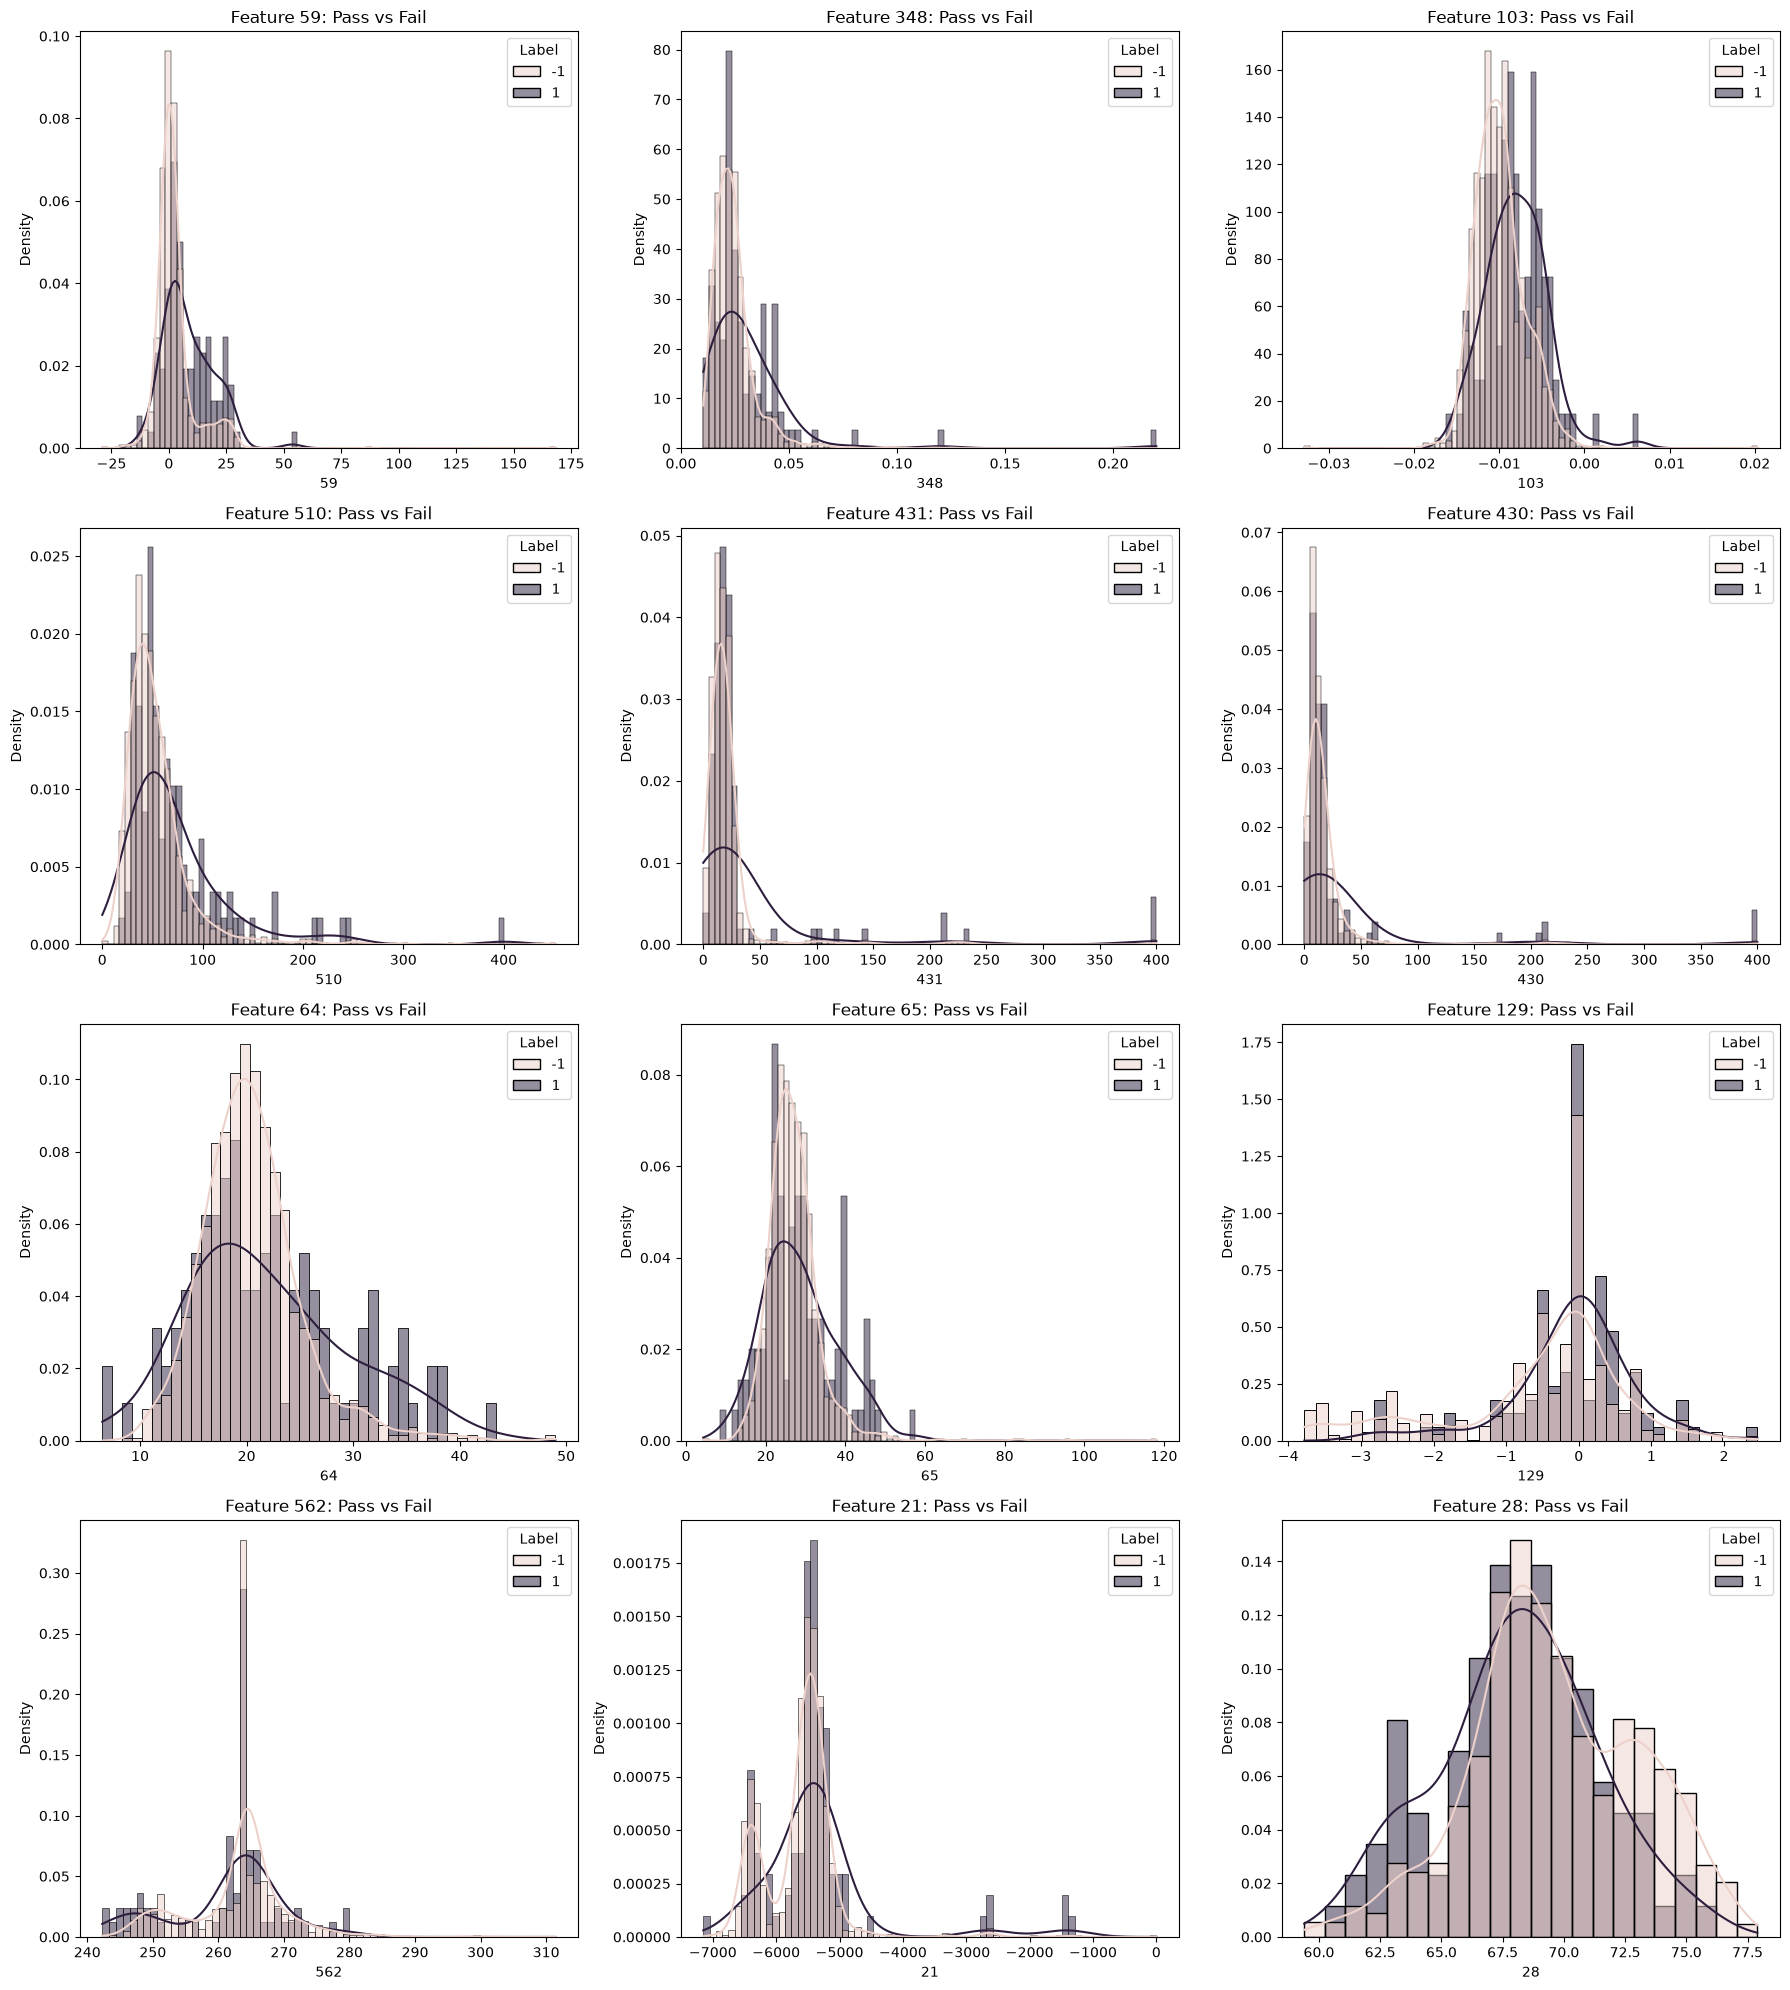

In [73]:
# for feature in features_to_plot:
#     sns.histplot(
#         data=df_no_constant_cols,
#         x=feature,
#         hue="Label",
#         kde=True,
#         stat="density",
#         common_norm=False
#     )

#     plt.title(f"Feature {feature}: Pass vs Fail")
#     plt.show()

cols = 3
rows = math.ceil(len(features_to_plot) / cols)

# figsize=(width, height) controls the overall size of the plot grid
# 18 is the total width, 5 * rows gives each row 5 inches of height
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))

# Flatten the axes array to easily iterate through it
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.histplot(
        data=df_no_constant_cols,
        x=feature,
        hue="Label",
        kde=True,
        stat="density",
        common_norm=False,
        ax=axes[i]  # Tell seaborn to plot on this specific subplot
    )
    
    axes[i].set_title(f"Feature {feature}: Pass vs Fail")

# Hide any empty subplots if the number of features isn't a perfect multiple of 3
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Adjusts spacing so titles and labels don't overlap
plt.tight_layout()
plt.show()


### Features intersect 

In [74]:
set(features_differ_most_between_pass_and_fail) & set(features_have_failures_in_extreme_ranges)

{59, 210, 294, 299, 348}

In [75]:
set(features_differ_most_between_pass_and_fail) & set(features_are_strongly_skewed)

set()

In [76]:
set(features_differ_most_between_pass_and_fail) & set(features_with_higher_outliers_rate)

{59, 129}

In [77]:
set(features_have_failures_in_extreme_ranges) & set(features_are_strongly_skewed)

{147, 282, 420}

In [78]:
set(features_have_failures_in_extreme_ranges) & set(features_with_higher_outliers_rate)

{41, 59, 562}

In [79]:
set(features_are_strongly_skewed) & set(features_with_higher_outliers_rate)

set()

### Check observation support for the EDA shortlist

A large effect can be unreliable when a feature is observed for only a small share of the failure class. The table below reports class-specific availability without imposing an arbitrary support cutoff.

In [80]:
n_pass_total = (df_no_constant_cols["Label"] == -1).sum()
n_fail_total = (df_no_constant_cols["Label"] == 1).sum()

eda_shortlist_support = (
    eda_shortlist
    .assign(
        pass_observed_rate=lambda d: d["pass_count"] / n_pass_total,
        fail_observed_rate=lambda d: d["fail_count"] / n_fail_total,
    )
    [
        [
            "feature",
            "n_observed",
            "missing_rate",
            "pass_count",
            "pass_observed_rate",
            "fail_count",
            "fail_observed_rate",
            "abs_standardized_mean_difference",
            "fail_extreme_rate",
        ]
    ]
    .sort_values("fail_observed_rate")
)

eda_shortlist_support

,feature,n_observed,missing_rate,pass_count,pass_observed_rate,fail_count,fail_observed_rate,abs_standardized_mean_difference,fail_extreme_rate
102,111,549,0.649649,519,0.354751,30,0.288462,0.503717,0.100000
208,247,852,0.456286,781,0.533835,71,0.682692,0.293657,0.070423
432,562,1294,0.174218,1214,0.829802,80,0.769231,0.203408,0.200000
338,430,1565,0.001276,1462,0.999316,103,0.990385,0.446322,0.145631
342,434,1565,0.001276,1462,0.999316,103,0.990385,0.454736,0.145631
244,298,1565,0.001276,1462,0.999316,103,0.990385,0.415378,0.165049
339,431,1565,0.001276,1462,0.999316,103,0.990385,0.490669,0.135922
343,435,1565,0.001276,1462,0.999316,103,0.990385,0.442217,0.165049
344,436,1565,0.001276,1462,0.999316,103,0.990385,0.433369,0.116505
151,164,1565,0.001276,1462,0.999316,103,0.990385,0.356242,0.155340


### Identify low-information signals

Raw variance is not comparable across anonymous measurements with different scales and units. Instead, a remaining feature is flagged as low-information when one observed value accounts for at least 98% of its non-missing observations. This describes concentration without automatically removing the feature.

In [81]:
process_features = df_no_constant_cols.drop(columns=["Label", "timestamp"])

current_signal_quality_report = constant_near_constant_report(
    process_features,
    near_constant_threshold=0.98,
)

dominance_rate_by_feature = (
    current_signal_quality_report
    .set_index("feature")["dominance_rate_non_missing"]
)

eda_report["dominance_rate_non_missing"] = (
    eda_report["feature"].map(dominance_rate_by_feature)
)
eda_report["flag_low_information"] = (
    eda_report["dominance_rate_non_missing"] >= 0.98
)

low_information_features = (
    current_signal_quality_report
    .loc[
        current_signal_quality_report["is_near_constant"],
        [
            "feature",
            "n_missing",
            "missing_rate",
            "n_unique_non_missing",
            "most_common_value",
            "most_common_count",
            "dominance_rate_non_missing",
        ],
    ]
    .sort_values("dominance_rate_non_missing", ascending=False)
)

low_information_features

,feature,n_missing,missing_rate,n_unique_non_missing,most_common_value,most_common_count,dominance_rate_non_missing
402,521,0,0.0,9,0.0,1546,0.986599
105,114,0,0.0,20,0.0,1545,0.985960
210,249,0,0.0,23,0.0,1545,0.985960
308,387,0,0.0,22,0.0,1545,0.985960


### Identify highly correlated and potentially redundant signals

Spearman correlation is used because many SECOM features are skewed or contain extreme values. Feature pairs with at least 100 paired observations and an absolute correlation of 0.95 or greater are flagged as potentially redundant. Correlation describes shared behavior; it does not prove that the anonymous measurements come from the same sensor or process step.

In [82]:
spearman_correlation = process_features.corr(
    method="spearman",
    min_periods=100,
)

upper_triangle_mask = np.triu(
    np.ones(spearman_correlation.shape, dtype=bool),
    k=1,
)

high_correlation_pairs = (
    spearman_correlation
    .where(upper_triangle_mask)
    .stack()
    .rename("spearman_correlation")
    .rename_axis(index=["feature_1", "feature_2"])
    .reset_index()
    .assign(
        abs_spearman_correlation=lambda d: (
            d["spearman_correlation"].abs()
        )
    )
    .loc[lambda d: d["abs_spearman_correlation"] >= 0.95]
    .sort_values("abs_spearman_correlation", ascending=False)
    .reset_index(drop=True)
)

redundant_features = pd.Index(
    pd.concat(
        [
            high_correlation_pairs["feature_1"],
            high_correlation_pairs["feature_2"],
        ],
        ignore_index=True,
    ).unique()
)

eda_report["flag_high_redundancy"] = (
    eda_report["feature"].isin(redundant_features)
)

print(f"Highly correlated pairs: {len(high_correlation_pairs)}")
print(f"Features participating in those pairs: {len(redundant_features)}")

high_correlation_pairs.head(50)

Highly correlated pairs: 224
Features participating in those pairs: 263


,feature_1,feature_2,spearman_correlation,abs_spearman_correlation
0,578,586,1.000000,1.000000
1,581,589,1.000000,1.000000
2,580,588,1.000000,1.000000
3,579,587,1.000000,1.000000
4,249,387,1.000000,1.000000
5,34,36,-1.000000,1.000000
6,307,309,0.999997,0.999997
7,172,174,0.999997,0.999997
8,114,387,0.999997,0.999997
9,114,249,0.999996,0.999996


### Process-signal taxonomy

The final Phase 5 taxonomy keeps overlapping behavior labels because one feature may be sparse, skewed, outlier-heavy, target-associated, and redundant at the same time. These labels describe the observed dataset and create investigation candidates; they are not final feature-selection decisions or causal process conclusions.

In [83]:
eda_report["fail_observed_rate"] = (
    eda_report["fail_count"] / n_fail_total
)

eda_report["support_level"] = pd.cut(
    eda_report["fail_observed_rate"],
    bins=[-np.inf, 0.50, 0.90, np.inf],
    labels=[
        "low failure support",
        "moderate failure support",
        "high failure support",
    ],
    right=False,
)

taxonomy_flags = {
    "missing-heavy": "flag_high_missing",
    "low-information / rare-state": "flag_low_information",
    "highly skewed": "flag_high_skew",
    "outlier-heavy": "flag_high_outlier_rate",
    "pass/fail-shifted": "flag_pass_fail_shift",
    "failure-extreme": "flag_failure_extreme",
    "highly redundant": "flag_high_redundancy",
}

def combine_behavior_labels(row):
    labels = [
        label
        for label, flag_column in taxonomy_flags.items()
        if bool(row[flag_column])
    ]
    return " | ".join(labels) if labels else "unflagged"

eda_report["behavior_taxonomy"] = eda_report.apply(
    combine_behavior_labels,
    axis=1,
)
eda_report["taxonomy_flag_count"] = eda_report[
    list(taxonomy_flags.values())
].sum(axis=1)

process_signal_taxonomy = (
    eda_report[
        [
            "feature",
            "missing_rate",
            "fail_count",
            "fail_observed_rate",
            "support_level",
            "dominance_rate_non_missing",
            "abs_standardized_mean_difference",
            "fail_extreme_rate",
            "outlier_rate",
            "skew",
            "behavior_taxonomy",
            "candidate_process_signal",
            "taxonomy_flag_count",
        ]
    ]
    .sort_values(
        [
            "candidate_process_signal",
            "taxonomy_flag_count",
            "abs_standardized_mean_difference",
        ],
        ascending=[False, False, False],
    )
    .reset_index(drop=True)
)

taxonomy_summary = (
    eda_report[list(taxonomy_flags.values())]
    .sum()
    .rename(index={value: key for key, value in taxonomy_flags.items()})
    .rename("feature_count")
    .to_frame()
)
taxonomy_summary["feature_percentage"] = (
    taxonomy_summary["feature_count"] / len(eda_report)
)

print(f"Taxonomy rows: {len(process_signal_taxonomy)}")
display(taxonomy_summary)
process_signal_taxonomy.head(50)

Taxonomy rows: 460


,feature_count,feature_percentage
missing-heavy,20,0.043478
low-information / rare-state,4,0.008696
highly skewed,259,0.563043
outlier-heavy,28,0.060870
pass/fail-shifted,37,0.080435
failure-extreme,2,0.004348
highly redundant,263,0.571739


,feature,missing_rate,fail_count,fail_observed_rate,support_level,dominance_rate_non_missing,abs_standardized_mean_difference,fail_extreme_rate,outlier_rate,skew,behavior_taxonomy,candidate_process_signal,taxonomy_flag_count
0,59,0.004467,104,1.000000,high failure support,0.001923,0.631888,0.173077,0.125641,4.719467,highly skewed | outlier-heavy | pass/fail-shifted,True,3
1,431,0.001276,103,0.990385,high failure support,0.004473,0.490669,0.135922,0.052396,7.098779,highly skewed | pass/fail-shifted | highly red...,True,3
2,430,0.001276,103,0.990385,high failure support,0.004473,0.446322,0.145631,0.074760,7.389605,highly skewed | pass/fail-shifted | highly red...,True,3
3,435,0.001276,103,0.990385,high failure support,0.004473,0.442217,0.165049,0.040895,8.660243,highly skewed | pass/fail-shifted | highly red...,True,3
4,298,0.001276,103,0.990385,high failure support,0.006390,0.415378,0.165049,0.029393,5.749743,highly skewed | pass/fail-shifted | highly red...,True,3
5,163,0.001276,103,0.990385,high failure support,0.013419,0.406417,0.145631,0.035144,5.261127,highly skewed | pass/fail-shifted | highly red...,True,3
6,295,0.001276,103,0.990385,high failure support,0.001278,0.373388,0.135922,0.046645,4.221393,highly skewed | pass/fail-shifted | highly red...,True,3
7,160,0.001276,103,0.990385,high failure support,0.005751,0.364607,0.135922,0.046006,3.993205,highly skewed | pass/fail-shifted | highly red...,True,3
8,164,0.001276,103,0.990385,high failure support,0.020447,0.356242,0.155340,0.038339,6.522125,highly skewed | pass/fail-shifted | highly red...,True,3
9,299,0.001276,103,0.990385,high failure support,0.007029,0.356183,0.165049,0.034505,6.669933,highly skewed | pass/fail-shifted | highly red...,True,3


### Phase 6

#### Signal-to-noise ratio and Welch's t-test

In [84]:
X = df_no_constant_cols.drop(columns=["Label", "timestamp"])
y = df_no_constant_cols.Label

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

##### Verify the split

In [86]:
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining labels:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nTest labels:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Training shape: (1253, 460)
Test shape: (314, 460)

Training labels:
Label
-1    1170
 1      83
Name: count, dtype: int64
Label
-1    0.933759
 1    0.066241
Name: proportion, dtype: float64

Test labels:
Label
-1    293
 1     21
Name: count, dtype: int64
Label
-1    0.933121
 1    0.066879
Name: proportion, dtype: float64


In [87]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import RFE

In [88]:
median_imputer = SimpleImputer(strategy="median")

In [89]:
X_train_imputed = median_imputer.fit_transform(X_train)

In [90]:
mi_scores = mutual_info_classif(
    X_train_imputed,
    y_train,
    discrete_features=False,
    n_neighbors=3,
    random_state=42
)

In [91]:
mi_ranking = (
    pd.DataFrame({
        "feature": X_train.columns,
        "mutual_information": mi_scores
    })
    .assign(
        mi_rank=lambda df:
            df["mutual_information"]
            .rank(method="min", ascending=False)
            .astype("Int64")
    )
    .sort_values("mutual_information", ascending=False)
    .reset_index(drop=True)
)

mi_ranking.head(20)

,feature,mutual_information,mi_rank
0,128,0.031549,1
1,541,0.030847,2
2,411,0.030745,3
3,274,0.029800,4
4,443,0.025717,5
5,269,0.025322,6
6,412,0.024856,7
7,91,0.024489,8
8,277,0.024017,9
9,416,0.023614,10


### RandomForest, SelectFromModel and REF

In [92]:
rf = RandomForestClassifier(n_estimators=500, min_samples_split=5, min_samples_leaf=1, n_jobs=-1, random_state=42)  

In [93]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [94]:
feature_importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_}).sort_values("Importance", ascending=False).reset_index(drop=True)

In [95]:
feature_importances

,Feature,Importance
0,64,0.013819
1,562,0.012878
2,65,0.009239
3,574,0.008705
4,103,0.008612
5,59,0.007496
6,16,0.007125
7,539,0.007076
8,153,0.006808
9,441,0.006740


In [96]:
selector = SelectFromModel(rf, threshold="median", prefit=True)
selector.fit(X_train, y_train)

,"estimator estimator: objectThe base estimator from which the transformer is built.This can be both a fitted (if ``prefit`` is set to True)or a non-fitted estimator. The estimator should have a``feature_importances_`` or ``coef_`` attribute after fitting.Otherwise, the ``importance_getter`` parameter should be used.",RandomForestC...ndom_state=42)
,"threshold threshold: str or float, default=NoneThe threshold value to use for feature selection. Features whoseabsolute importance value is greater or equal are kept while the othersare discarded. If ""median"" (resp. ""mean""), then the ``threshold`` valueis the median (resp. the mean) of the feature importances. A scalingfactor (e.g., ""1.25*mean"") may also be used. If None and if theestimator has a parameter penalty set to l1, either explicitlyor implicitly (e.g, Lasso), the threshold used is 1e-5.Otherwise, ""mean"" is used by default.",'median'
,"prefit prefit: bool, default=FalseWhether a prefit model is expected to be passed into the constructordirectly or not.If `True`, `estimator` must be a fitted estimator.If `False`, `estimator` is fitted and updated by calling`fit` and `partial_fit`, respectively.",True
,"norm_order norm_order: non-zero int, inf, -inf, default=1Order of the norm used to filter the vectors of coefficients below``threshold`` in the case where the ``coef_`` attribute of theestimator is of dimension 2.",1
,"max_features max_features: int, callable, default=NoneThe maximum number of features to select.- If an integer, then it specifies the maximum number of features to allow.- If a callable, then it specifies how to calculate the maximum number of features allowed. The callable will receive `X` as input: `max_features(X)`.- If `None`, then all features are kept.To only select based on ``max_features``, set ``threshold=-np.inf``... versionadded:: 0.20.. versionchanged:: 1.1 `max_features` accepts a callable.",None
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a ``coef_``attribute or ``feature_importances_`` attribute of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
"estimator_ estimator_: estimatorThe base estimator from which the transformer is built. This attributeexist only when `fit` has been called.- If `prefit=True`, it is a deep copy of `estimator`.- If `prefit=False`, it is a clone of `estimator` and fit on the data passed to `fit` or `partial_fit`.",RandomForestClassifier,RandomForestC...ndom_state=42)
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,460
threshold_ threshold_: floatThe threshold value used for feature selection.,float64,0.00176
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500


In [97]:
selected_features = selector.get_support(indices=True)

# Print selected feature names
selected_feature_names = [X_train.columns[i] for i in selected_features]
print("Selected Features:", selected_feature_names)

Selected Features: [0, 2, 4, 7, 10, 11, 12, 16, 21, 22, 25, 26, 27, 33, 38, 40, 41, 45, 48, 51, 54, 55, 58, 59, 61, 62, 63, 64, 65, 67, 71, 72, 73, 75, 77, 78, 80, 81, 82, 83, 88, 89, 93, 96, 99, 100, 102, 103, 104, 106, 107, 108, 112, 114, 117, 119, 120, 121, 123, 124, 126, 128, 129, 132, 135, 138, 139, 144, 146, 147, 148, 152, 153, 154, 156, 160, 164, 166, 168, 169, 170, 173, 188, 195, 197, 199, 200, 203, 204, 205, 208, 210, 211, 212, 213, 214, 216, 217, 218, 222, 223, 225, 227, 239, 245, 247, 248, 249, 250, 253, 267, 269, 270, 271, 273, 279, 282, 285, 287, 288, 289, 291, 295, 298, 299, 301, 302, 304, 305, 308, 311, 324, 331, 332, 333, 335, 336, 339, 341, 344, 345, 346, 348, 349, 350, 352, 354, 356, 360, 361, 363, 365, 376, 377, 385, 386, 387, 388, 391, 405, 406, 407, 408, 411, 412, 413, 420, 421, 423, 425, 426, 427, 429, 430, 431, 433, 434, 435, 437, 439, 440, 441, 444, 453, 456, 460, 467, 469, 471, 472, 473, 475, 476, 477, 486, 494, 497, 500, 510, 516, 519, 523, 525, 539, 541, 546,

In [98]:
rf_rfe = RandomForestClassifier(
    n_estimators=150,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    n_jobs=1,
    random_state=42
)

In [99]:
rfe = RFE(estimator=rf_rfe, n_features_to_select=40, step=0.10, importance_getter="feature_importances_", verbose=1)
rfe.fit(X_train, y_train)

Fitting estimator with 460 features.
Fitting estimator with 414 features.
Fitting estimator with 368 features.
Fitting estimator with 322 features.
Fitting estimator with 276 features.
Fitting estimator with 230 features.
Fitting estimator with 184 features.
Fitting estimator with 138 features.
Fitting estimator with 92 features.
Fitting estimator with 46 features.


,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",RandomForestC...ndom_state=42)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",40
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",0.1
,"verbose verbose: int, default=0Controls verbosity of output.",1
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'feature_importances_'
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only available when `estimator` is a classifier.","ndarray[int64](2,)","[-1, 1]"
estimator_ estimator_: ``Estimator`` instanceThe fitted estimator used to select features.,RandomForestClassifier,RandomForestC...ndom_state=42)
n_features_ n_features_: intThe number of selected features.,int64,np.int64(40)
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,460
"ranking_ ranking_: ndarray of shape (n_features,)The feature ranking, such that ``ranking_[i]`` corresponds to theranking position of the i-th feature. Selected (i.e., estimatedbest) features are assigned rank 1.","ndarray[int64](460,)","[1,5,9,...,3,3,8]"


In [100]:
rfe_ranking = (
    pd.DataFrame({
        "feature": X_train.columns,
        "selected": rfe.support_,
        "rfe_rank": rfe.ranking_
    })
    .sort_values(
        ["selected", "rfe_rank"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

selected_features_rfe = rfe_ranking.loc[
    rfe_ranking["selected"],
    "feature"
].tolist()

print("Number selected:", len(selected_features_rfe))
print("Selected features:", selected_features_rfe)

rfe_ranking.head(40)

Number selected: 40
Selected features: [0, 21, 31, 33, 39, 58, 59, 64, 65, 86, 90, 91, 102, 103, 121, 125, 129, 130, 132, 146, 156, 182, 183, 200, 205, 213, 218, 247, 281, 319, 341, 351, 390, 410, 423, 446, 477, 489, 510, 519]


,feature,selected,rfe_rank
0,0,True,1
1,21,True,1
2,31,True,1
3,33,True,1
4,39,True,1
5,58,True,1
6,59,True,1
7,64,True,1
8,65,True,1
9,86,True,1


### PCA

In [101]:
pca_pipeline= Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ('scaler', StandardScaler()),
        ("PCA", PCA())
    ]
)

In [102]:
X_train_pca = pca_pipeline.fit_transform(X_train)

In [103]:
pca_model = pca_pipeline.named_steps["PCA"]

In [104]:
print("Original training shape:", X_train.shape)
print("PCA training shape:", X_train_pca.shape)

Original training shape: (1253, 460)
PCA training shape: (1253, 460)


In [105]:
explained_variance = pca_model.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

def components_needed(threshold):
    return np.searchsorted(
        cumulative_variance,
        threshold
    ) + 1

print(
    "Components for 80% variance:",
    components_needed(0.80)
)
print(
    "Components for 90% variance:",
    components_needed(0.90)
)
print(
    "Components for 95% variance:",
    components_needed(0.95)
)

pca_variance_report = pd.DataFrame({
    "component": np.arange(
        1,
        len(explained_variance) + 1
    ),
    "explained_variance": explained_variance,
    "cumulative_variance": cumulative_variance
})

pca_variance_report.head(20)

Components for 80% variance: 87
Components for 90% variance: 129
Components for 95% variance: 164


,component,explained_variance,cumulative_variance
0,1,0.056195,0.056195
1,2,0.037232,0.093427
2,3,0.029440,0.122867
3,4,0.026083,0.148950
4,5,0.022992,0.171942
5,6,0.021562,0.193504
6,7,0.020364,0.213868
7,8,0.018742,0.232610
8,9,0.016967,0.249577
9,10,0.014683,0.264260


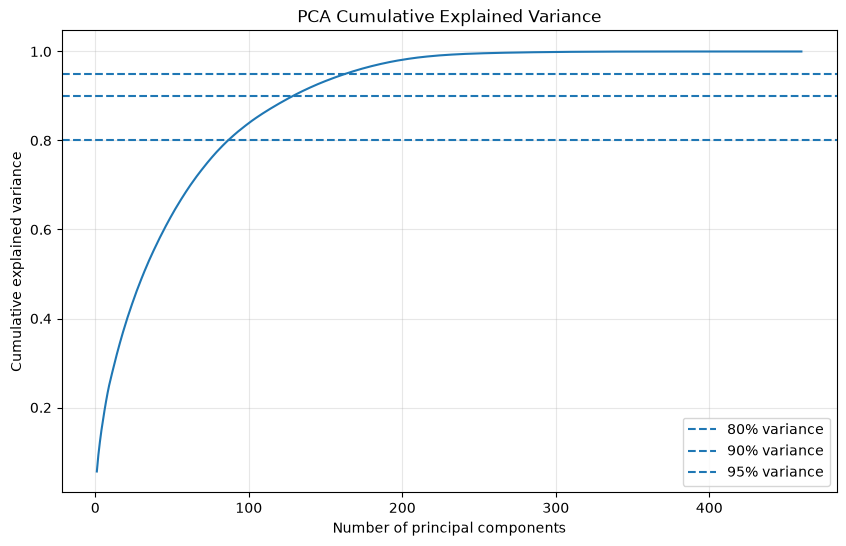

In [106]:
plt.figure(figsize=(10, 6))

plt.plot(
    pca_variance_report["component"],
    pca_variance_report["cumulative_variance"]
)

for threshold in [0.80, 0.90, 0.95]:
    plt.axhline(
        threshold,
        linestyle="--",
        label=f"{threshold:.0%} variance"
    )

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

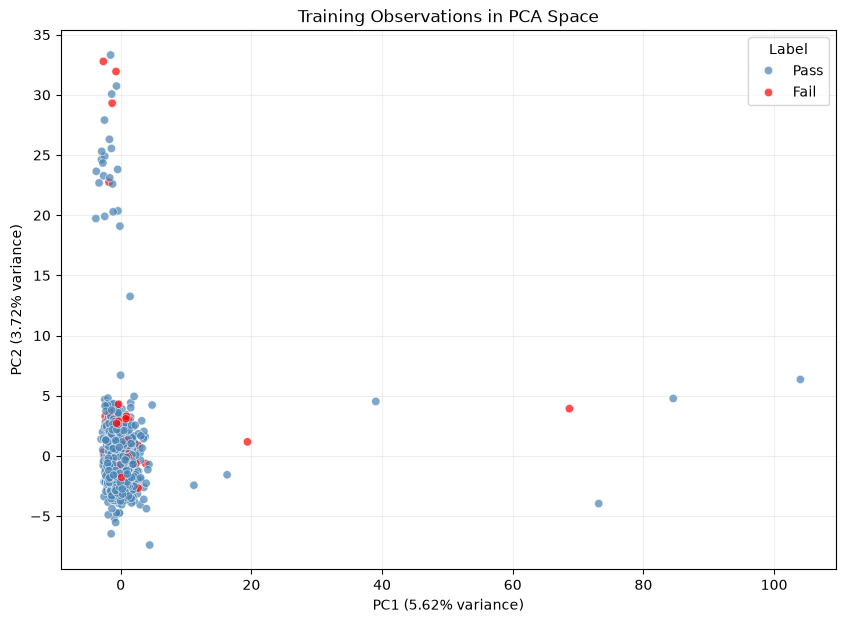

In [107]:
pca_projection = pd.DataFrame(
    {
        "PC1": X_train_pca[:, 0],
        "PC2": X_train_pca[:, 1],
        "Label": y_train.map({
            -1: "Pass",
            1: "Fail"
        }).values
    },
    index=X_train.index
)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_projection,
    x="PC1",
    y="PC2",
    hue="Label",
    hue_order=["Pass", "Fail"],
    palette={
        "Pass": "steelblue",
        "Fail": "red"
    },
    alpha=0.70
)

plt.xlabel(
    f"PC1 ({explained_variance[0]:.2%} variance)"
)
plt.ylabel(
    f"PC2 ({explained_variance[1]:.2%} variance)"
)
plt.title("Training Observations in PCA Space")
plt.grid(alpha=0.2)
plt.show()

### Phase 7

#### Baseline Model Pipeline

In [108]:
base_line_pipeline = create_pipeline(
    threshold=0.80,
    use_correlation=False,
    imputer=SimpleImputer(strategy="median"),
    scaler=StandardScaler(), 
    classifier=LogisticRegression(class_weight="balanced", max_iter=5000,random_state=42),
)

In [109]:
base_line_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('drop_high_missing', ...), ('drop_correlated', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[-1, 1]"
,threshold,0.8
Name,Type,Value
features_to_drop_,list,[]
features_to_keep_,list,"[0, 1, 2, 3, ...]"
missing_rate_,"Series[float64](460,)",0 0.0039...dtype: float64


In [110]:
base_line_pipeline.score(X_train, y_train)

0.9784517158818835

In [111]:
baseline_cv_summary, baseline_cv_scores = evaluate_pipeline_cv(
    pipeline=base_line_pipeline,
    X=X_train,
    y=y_train,
    pipeline_name="All 460 features",
    n_splits=5,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)

In [112]:
baseline_cv_summary

,pipeline,balanced_accuracy_mean,balanced_accuracy_std,ber_mean,ber_std,failure_recall_mean,failure_recall_std,false_negative_rate_mean,failure_precision_mean,failure_precision_std,failure_f1_mean,failure_f1_std,average_precision_mean,average_precision_std,mean_fit_time
0,All 460 features,0.578739,0.058539,0.421261,0.058539,0.265,0.116742,0.735,0.147533,0.059118,0.18847,0.076974,0.153862,0.053631,0.216053


#### Correlation Prune Model Pipeline

In [113]:
rf = RandomForestClassifier(n_estimators=500, 
                            class_weight="balanced_subsample",
                            max_depth=8,
                            min_samples_split=10, 
                            min_samples_leaf=4,
                            max_features="sqrt",
                            bootstrap=True,
                            n_jobs=1, 
                            random_state=42)

In [114]:
correlation_prune_40_features = create_pipeline(
    threshold=0.80,
    use_correlation=True,
    correlation_threshold=0.90,
    correlation_method="spearman",
    min_periods=100,
    scaler=None,
    selector=RFE(estimator=rf_rfe, n_features_to_select=40, step=0.10, importance_getter="feature_importances_", verbose=1),
    classifier=rf)

In [115]:
correlation_prune_40_features.fit(X_train, y_train)

Fitting estimator with 261 features.
Fitting estimator with 235 features.
Fitting estimator with 209 features.
Fitting estimator with 183 features.
Fitting estimator with 157 features.
Fitting estimator with 131 features.
Fitting estimator with 105 features.
Fitting estimator with 79 features.
Fitting estimator with 53 features.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('drop_high_missing', ...), ('drop_correlated', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[-1, 1]"
,threshold,0.8
Name,Type,Value
features_to_drop_,list,[]
features_to_keep_,list,"[0, 1, 2, 3, ...]"
missing_rate_,"Series[float64](460,)",0 0.0039...dtype: float64


In [116]:
correlation_prune_40_features.score(X_train, y_train)

1.0

In [117]:
correlation_prune_40_features_cv_summary, correlation_prune_40_features_cv_scores = evaluate_pipeline_cv(
    pipeline=correlation_prune_40_features,
    X=X_train,
    y=y_train,
    pipeline_name="correlation_prune_40_features",
    n_splits=5,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)

Fitting estimator with 261 features.
Fitting estimator with 235 features.
Fitting estimator with 260 features.
Fitting estimator with 209 features.
Fitting estimator with 234 features.
Fitting estimator with 183 features.
Fitting estimator with 208 features.
Fitting estimator with 157 features.
Fitting estimator with 182 features.
Fitting estimator with 131 features.
Fitting estimator with 156 features.
Fitting estimator with 105 features.
Fitting estimator with 130 features.
Fitting estimator with 79 features.
Fitting estimator with 104 features.
Fitting estimator with 53 features.
Fitting estimator with 78 features.
Fitting estimator with 52 features.
Fitting estimator with 261 features.
Fitting estimator with 260 features.
Fitting estimator with 235 features.
Fitting estimator with 234 features.
Fitting estimator with 209 features.
Fitting estimator with 208 features.
Fitting estimator with 183 features.
Fitting estimator with 182 features.
Fitting estimator with 157 features.
Fitti

In [118]:
correlation_prune_40_features_cv_summary

,pipeline,balanced_accuracy_mean,balanced_accuracy_std,ber_mean,ber_std,failure_recall_mean,failure_recall_std,false_negative_rate_mean,failure_precision_mean,failure_precision_std,failure_f1_mean,failure_f1_std,average_precision_mean,average_precision_std,mean_fit_time
0,correlation_prune_40_features,0.504715,0.015609,0.495285,0.015609,0.014559,0.031377,0.985441,0.146,0.328,0.025023,0.052242,0.183493,0.042318,40.382345


#### Second run

In [119]:
correlation_prune_40_features_2 = create_pipeline(
    threshold=0.50,
    use_correlation=True,
    correlation_threshold=0.90,
    correlation_method="spearman",
    min_periods=100,
    imputer=None,
    scaler=None,
    classifier=rf)

In [120]:
correlation_prune_40_features_2.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('drop_high_missing', ...), ('drop_correlated', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[-1, 1]"
,threshold,0.5
Name,Type,Value
features_to_drop_,list,"[109, 110, 111, 244, ...]"
features_to_keep_,list,"[0, 1, 2, 3, ...]"
missing_rate_,"Series[float64](460,)",0 0.0039...dtype: float64


In [121]:
correlation_prune_40_features_2_cv_summary, correlation_prune_40_features_2_cv_scores = evaluate_pipeline_cv(
    pipeline=correlation_prune_40_features_2,
    X=X_train,
    y=y_train,
    pipeline_name="correlation_prune_40_features_2",
    n_splits=5,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)

In [122]:
correlation_prune_40_features_2_cv_summary

,pipeline,balanced_accuracy_mean,balanced_accuracy_std,ber_mean,ber_std,failure_recall_mean,failure_recall_std,false_negative_rate_mean,failure_precision_mean,failure_precision_std,failure_f1_mean,failure_f1_std,average_precision_mean,average_precision_std,mean_fit_time
0,correlation_prune_40_features_2,0.5,0.0,0.5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.198783,0.05241,27.576375


### Using ANOVA

In [123]:
from sklearn.feature_selection import SelectKBest, f_classif

select_kbest_100_pipeline = create_pipeline(
    threshold=0.80,
    use_correlation=False,
    imputer=SimpleImputer(strategy="median"),
    selector=SelectKBest(
        score_func=f_classif,
        k=100,
    ),
    scaler=StandardScaler(),
    reducer=None,
    classifier=rf
)

In [124]:
select_kbest_100_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('drop_high_missing', ...), ('drop_correlated', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[-1, 1]"
,threshold,0.8
Name,Type,Value
features_to_drop_,list,[]
features_to_keep_,list,"[0, 1, 2, 3, ...]"
missing_rate_,"Series[float64](460,)",0 0.0039...dtype: float64


In [125]:
select_kbest_100_pipeline_cv_summary, select_kbest_100_pipeline_2_cv_scores = evaluate_pipeline_cv(
    pipeline=select_kbest_100_pipeline,
    X=X_train,
    y=y_train,
    pipeline_name="select_kbest_100_pipeline",
    n_splits=5,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)

In [126]:
select_kbest_100_pipeline_cv_summary

,pipeline,balanced_accuracy_mean,balanced_accuracy_std,ber_mean,ber_std,failure_recall_mean,failure_recall_std,false_negative_rate_mean,failure_precision_mean,failure_precision_std,failure_f1_mean,failure_f1_std,average_precision_mean,average_precision_std,mean_fit_time
0,select_kbest_100_pipeline,0.50684,0.015903,0.49316,0.015903,0.014706,0.031592,0.985294,0.18,0.370945,0.026928,0.057318,0.191059,0.065198,3.048601


### Optuna Experiment

In [127]:
optuna_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

#### Pipeline builder

In [128]:
def build_optuna_pipeline(params):
    model_name = params["model"]
    k_features = params["k_features"]

    selector = SelectKBest(
        score_func=f_classif,
        k=k_features,
    )

    if model_name == "logistic_regression":
        classifier = LogisticRegression(
            C=params["lr_C"],
            l1_ratio=params["lr_l1_ratio"],
            solver="saga",
            class_weight="balanced",
            max_iter=5000,
            random_state=42,
        )

        scaler = StandardScaler()

    elif model_name == "random_forest":
        classifier = RandomForestClassifier(
            n_estimators=params["rf_n_estimators"],
            max_depth=params["rf_max_depth"],
            min_samples_split=params["rf_min_samples_split"],
            min_samples_leaf=params["rf_min_samples_leaf"],
            max_features=params["rf_max_features"],
            class_weight="balanced_subsample",
            bootstrap=True,
            n_jobs=1,
            random_state=42,
        )

        scaler = None

    elif model_name == "hist_gradient_boosting":
        classifier = HistGradientBoostingClassifier(
            learning_rate=params["hgb_learning_rate"],
            max_iter=params["hgb_max_iter"],
            max_leaf_nodes=params["hgb_max_leaf_nodes"],
            min_samples_leaf=params["hgb_min_samples_leaf"],
            l2_regularization=params["hgb_l2_regularization"],
            class_weight="balanced",
            early_stopping=True,
            random_state=42,
        )

        scaler = None

    return create_pipeline(
        threshold=0.80,
        use_correlation=False,
        imputer=SimpleImputer(strategy="median"),
        selector=selector,
        scaler=scaler,
        reducer=None,
        classifier=classifier,
    )

In [129]:
def objective(trial):
    model_name = trial.suggest_categorical(
        "model",
        [
            "logistic_regression",
            "random_forest",
            "hist_gradient_boosting",
        ],
    )

    trial.suggest_categorical(
        "k_features",
        [40, 70, 100],
    )

    if model_name == "logistic_regression":
        trial.suggest_float(
            "lr_C",
            1e-3,
            100,
            log=True,
        )

        trial.suggest_float(
            "lr_l1_ratio",
            0.0,
            1.0,
            step=0.1,
        )

    elif model_name == "random_forest":
        trial.suggest_int(
            "rf_n_estimators",
            300,
            700,
            step=100,
        )

        trial.suggest_categorical(
            "rf_max_depth",
            [4, 6, 8, 10, 12, None],
        )

        trial.suggest_int(
            "rf_min_samples_split",
            4,
            20,
            step=2,
        )

        trial.suggest_int(
            "rf_min_samples_leaf",
            2,
            12,
        )

        trial.suggest_categorical(
            "rf_max_features",
            ["sqrt", "log2", 0.3, 0.5],
        )

    elif model_name == "hist_gradient_boosting":
        trial.suggest_float(
            "hgb_learning_rate",
            0.01,
            0.20,
            log=True,
        )

        trial.suggest_int(
            "hgb_max_iter",
            100,
            400,
            step=50,
        )

        trial.suggest_int(
            "hgb_max_leaf_nodes",
            7,
            31,
            step=4,
        )

        trial.suggest_int(
            "hgb_min_samples_leaf",
            10,
            50,
            step=5,
        )

        trial.suggest_float(
            "hgb_l2_regularization",
            1e-4,
            10,
            log=True,
        )

    pipeline = build_optuna_pipeline(trial.params)

    scores = cross_val_score(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=optuna_cv,
        scoring="average_precision",
        n_jobs=-1,
        error_score="raise",
    )

    return scores.mean()

#### Run study

In [130]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)

study.optimize(
    objective,
    n_trials=50,
    n_jobs=1,
)

[I 2026-08-27 16:28:18,727] A new study created in memory with name: no-name-03359c62-962b-4084-878b-87d37c09108c
[I 2026-08-27 16:28:25,917] Trial 0 finished with value: 0.1965242903320064 and parameters: {'model': 'random_forest', 'k_features': 40, 'rf_n_estimators': 300, 'rf_max_depth': 12, 'rf_min_samples_split': 6, 'rf_min_samples_leaf': 4, 'rf_max_features': 0.3}. Best is trial 0 with value: 0.1965242903320064.
[I 2026-08-27 16:28:36,886] Trial 1 finished with value: 0.20788729422546828 and parameters: {'model': 'random_forest', 'k_features': 100, 'rf_n_estimators': 600, 'rf_max_depth': 12, 'rf_min_samples_split': 4, 'rf_min_samples_leaf': 12, 'rf_max_features': 'sqrt'}. Best is trial 1 with value: 0.20788729422546828.
[I 2026-08-27 16:28:38,960] Trial 2 finished with value: 0.1580498978345315 and parameters: {'model': 'logistic_regression', 'k_features': 100, 'lr_C': 0.01967432802530612, 'lr_l1_ratio': 0.7000000000000001}. Best is trial 1 with value: 0.20788729422546828.
[I 2026

#### Inspect the result

In [131]:
print("Best average precision:", study.best_value)
print("Best parameters:")

study.best_params

Best average precision: 0.2308462901576874
Best parameters:


{'model': 'random_forest',
 'k_features': 100,
 'rf_n_estimators': 500,
 'rf_max_depth': 10,
 'rf_min_samples_split': 12,
 'rf_min_samples_leaf': 8,
 'rf_max_features': 'log2'}

In [132]:
optuna_results = (
    study.trials_dataframe()
    .sort_values("value", ascending=False)
    .reset_index(drop=True)
)

optuna_results.head(10)

,number,value,datetime_start,datetime_complete,duration,params_hgb_l2_regularization,params_hgb_learning_rate,params_hgb_max_iter,params_hgb_max_leaf_nodes,params_hgb_min_samples_leaf,params_k_features,params_lr_C,params_lr_l1_ratio,params_model,params_rf_max_depth,params_rf_max_features,params_rf_min_samples_leaf,params_rf_min_samples_split,params_rf_n_estimators,state
0,32,0.230846,2026-08-27 16:34:01.754681,2026-08-27 16:34:10.167802,0 days 00:00:08.413121,NaN,NaN,NaN,NaN,NaN,100,NaN,NaN,random_forest,10.0,log2,8.0,12.0,500.0,COMPLETE
1,33,0.230846,2026-08-27 16:34:10.169931,2026-08-27 16:34:18.202123,0 days 00:00:08.032192,NaN,NaN,NaN,NaN,NaN,100,NaN,NaN,random_forest,10.0,log2,8.0,8.0,500.0,COMPLETE
2,34,0.230846,2026-08-27 16:34:18.203576,2026-08-27 16:34:26.159593,0 days 00:00:07.956017,NaN,NaN,NaN,NaN,NaN,100,NaN,NaN,random_forest,10.0,log2,8.0,12.0,500.0,COMPLETE
3,41,0.230846,2026-08-27 16:35:38.027452,2026-08-27 16:35:46.298071,0 days 00:00:08.270619,NaN,NaN,NaN,NaN,NaN,100,NaN,NaN,random_forest,10.0,log2,8.0,6.0,500.0,COMPLETE
4,40,0.230846,2026-08-27 16:35:30.037508,2026-08-27 16:35:38.026588,0 days 00:00:07.989080,NaN,NaN,NaN,NaN,NaN,100,NaN,NaN,random_forest,10.0,log2,8.0,6.0,500.0,COMPLETE
5,23,0.226096,2026-08-27 16:33:04.849378,2026-08-27 16:33:11.623012,0 days 00:00:06.773634,NaN,NaN,NaN,NaN,NaN,100,NaN,NaN,random_forest,NaN,log2,8.0,10.0,400.0,COMPLETE
6,16,0.226039,2026-08-27 16:32:09.412330,2026-08-27 16:32:18.895788,0 days 00:00:09.483458,NaN,NaN,NaN,NaN,NaN,100,NaN,NaN,random_forest,12.0,log2,8.0,10.0,600.0,COMPLETE
7,43,0.225452,2026-08-27 16:35:54.297448,2026-08-27 16:36:02.545283,0 days 00:00:08.247835,NaN,NaN,NaN,NaN,NaN,100,NaN,NaN,random_forest,10.0,log2,7.0,6.0,500.0,COMPLETE
8,26,0.224210,2026-08-27 16:33:25.162117,2026-08-27 16:33:30.522299,0 days 00:00:05.360182,NaN,NaN,NaN,NaN,NaN,100,NaN,NaN,random_forest,10.0,log2,8.0,8.0,300.0,COMPLETE
9,42,0.224201,2026-08-27 16:35:46.298898,2026-08-27 16:35:54.295485,0 days 00:00:07.996587,NaN,NaN,NaN,NaN,NaN,100,NaN,NaN,random_forest,10.0,log2,9.0,6.0,500.0,COMPLETE


#### Rebuild and evaluate the winning pipeline

In [133]:
best_optuna_pipeline = build_optuna_pipeline(
    study.best_params
)

best_optuna_cv_summary, best_optuna_cv_scores = (
    evaluate_pipeline_cv(
        pipeline=best_optuna_pipeline,
        X=X_train,
        y=y_train,
        pipeline_name="Optuna best pipeline",
        n_splits=5,
        n_repeats=5,
        random_state=42,
        n_jobs=-1,
    )
)

best_optuna_cv_summary

,pipeline,balanced_accuracy_mean,balanced_accuracy_std,ber_mean,ber_std,failure_recall_mean,failure_recall_std,false_negative_rate_mean,failure_precision_mean,failure_precision_std,failure_f1_mean,failure_f1_std,average_precision_mean,average_precision_std,mean_fit_time
0,Optuna best pipeline,0.508412,0.021172,0.491588,0.021172,0.019559,0.041422,0.980441,0.186667,0.378065,0.034881,0.073156,0.200041,0.062677,2.661311
